# Invoice Information Extraction — LayoutLMv3 + CORD

**Multi-modal receipt understanding** using Microsoft's LayoutLMv3 (text + layout + image patches) fine-tuned on the CORD v2 + SROIE receipt datasets.

**Pipeline:**
```
Receipt image
    ↓
EasyOCR (text + bounding boxes)
    ↓
LayoutLMv3Processor (text + boxes + image patches  →  token sequence)
    ↓
LayoutLMv3 token classification (33 entity classes)
    ↓
Structured JSON  +  annotated image
```

**Fields extracted (~33):** item name, qty, unit price, line total, subtotal, tax, total, cash, change, discount, service charge, vendor name, vendor address, receipt date, etc.

> Designed for **Lightning.ai Studio** — upload this notebook, select a GPU machine, and run top to bottom.

## 1 — Setup

In [23]:
!pip install -q "transformers>=4.30" datasets accelerate easyocr gradio Pillow seqeval scikit-learn
print("Dependencies installed.")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Dependencies installed.


In [ ]:
import os
import json
import re
import torch
import numpy as np
from collections import Counter
from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset
from transformers import (
    LayoutLMv3Processor,
    LayoutLMv3ForTokenClassification,
    TrainingArguments,
    Trainer,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2 — Load CORD v2 Dataset

CORD = Consolidated Receipt Dataset (NAVER CLOVA). 1,000 receipts with 30 entity classes — item names, quantities, prices, subtotals, taxes, totals, payments, change. Loaded straight from the HuggingFace hub.

In [25]:
print("Downloading CORD v2 from HuggingFace...")
dataset = load_dataset("naver-clova-ix/cord-v2")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})


In [26]:
# Peek at one sample to see the structure
sample = dataset["train"][0]
print("Image size :", sample["image"].size)

gt = json.loads(sample["ground_truth"])
print("GT keys    :", list(gt.keys()))
print(f"\nValid-line entries: {len(gt['valid_line'])}\n")

for line in gt["valid_line"][:4]:
    txts = ' '.join(w["text"] for w in line["words"])
    print(f"  [{line['category']:>30}]  {txts[:70]}")

Image size : (864, 1296)
GT keys    : ['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare']

Valid-line entries: 71

  [                      menu.cnt]  1 x
  [                       menu.nm]  Nasi Campur Bali
  [                    menu.price]  75,000
  [                      menu.cnt]  1 x


In [27]:
def parse_cord(ground_truth, img_w, img_h):
    """Parse CORD ground_truth JSON into (words, normalized_bboxes, label_strs).

    Each word in CORD has a 'quad' = 4 corner points and a 'category' on its parent line.
    """
    if isinstance(ground_truth, str):
        gt = json.loads(ground_truth)
    else:
        gt = ground_truth

    words, boxes, labels = [], [], []
    for line in gt.get("valid_line", []):
        category = line.get("category", "O")
        for w in line.get("words", []):
            text = w.get("text", "").strip()
            quad = w.get("quad", {})
            if not text or not quad:
                continue
            xs = [quad.get(f"x{i}", 0) for i in (1, 2, 3, 4)]
            ys = [quad.get(f"y{i}", 0) for i in (1, 2, 3, 4)]
            x1, y1 = min(xs), min(ys)
            x2, y2 = max(xs), max(ys)
            box = [
                max(0, min(1000, int(x1 * 1000 / img_w))),
                max(0, min(1000, int(y1 * 1000 / img_h))),
                max(0, min(1000, int(x2 * 1000 / img_w))),
                max(0, min(1000, int(y2 * 1000 / img_h))),
            ]
            # Guarantee monotonic box
            if box[2] < box[0]: box[2] = box[0]
            if box[3] < box[1]: box[3] = box[1]
            words.append(text)
            boxes.append(box)
            labels.append(category)
    return words, boxes, labels


# Build the label vocabulary by scanning the training set
label_counter = Counter()
for example in dataset["train"]:
    gt = json.loads(example["ground_truth"])
    for line in gt.get("valid_line", []):
        label_counter[line.get("category", "O")] += 1

labels_list = ["O"] + sorted(label_counter.keys())
label2id = {l: i for i, l in enumerate(labels_list)}
id2label = {i: l for i, l in enumerate(labels_list)}

print(f"Distinct labels: {len(labels_list)}")
print("Top-10 most common:")
for lbl, cnt in label_counter.most_common(13):
    print(f"  {lbl:>32}  {cnt:>6}")

Distinct labels: 30
Top-10 most common:
                           menu.nm    2100
                        menu.price    2093
                          menu.cnt    1903
                 total.total_price     784
                    menu.unitprice     621
          sub_total.subtotal_price     541
                   total.cashprice     526
                 total.changeprice     502
               sub_total.tax_price     362
                       menu.sub.nm     319
                 total.menuqty_cnt     233
                      menu.sub.cnt     142
             total.creditcardprice     124


## 3 — LayoutLMv3 Preprocessing

The processor wraps an image processor (resizes to 224×224, splits into 14×14 patches) **and** a tokenizer (RoBERTa BPE). It produces a unified sequence of text tokens **and** image patch embeddings — that's the v3 innovation over v1.

In [28]:
processor = LayoutLMv3Processor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False,   # We pass our own OCR results from CORD
)
print("LayoutLMv3 processor ready.")

LayoutLMv3 processor ready.


In [29]:
def preprocess_batch(examples):
    """Batched processor: takes a chunk of CORD examples, returns LayoutLMv3 encodings.

    Run inside `.map(batched=True, ...)` so HF datasets caches results to disk
    instead of keeping them all in RAM (eager preprocessing crashed the kernel).
    """
    images = [img.convert("RGB") for img in examples["image"]]

    batch_words, batch_boxes, batch_labels = [], [], []
    for img, gt in zip(images, examples["ground_truth"]):
        w, h = img.size
        words, boxes, lbl_strs = parse_cord(gt, w, h)
        if not words:
            # Empty samples break batching; insert a single throwaway token
            words, boxes, lbl_strs = ["empty"], [[0, 0, 0, 0]], ["O"]
        label_ids = [label2id.get(l, 0) for l in lbl_strs]
        batch_words.append(words)
        batch_boxes.append(boxes)
        batch_labels.append(label_ids)

    return processor(
        images=images,
        text=batch_words,
        boxes=batch_boxes,
        word_labels=batch_labels,
        truncation=True,
        padding="max_length",
    )


print("Preprocessing splits with HF datasets .map() (results cached to disk)...")
processed = dataset.map(
    preprocess_batch,
    batched=True,
    batch_size=4,
    remove_columns=["image", "ground_truth"],
)

# IMPORTANT: do NOT call processed.set_format("torch") — it triggers a buggy
# `from torchvision.io import VideoReader` inside datasets' torch_formatter
# on current Colab. We wrap the dataset manually instead.

class TensorWrapper(torch.utils.data.Dataset):
    """Returns each HF example as a dict of torch tensors at __getitem__ time."""
    def __init__(self, hf_ds):
        self.ds = hf_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        return {k: torch.as_tensor(v) for k, v in item.items()}


train_ds = TensorWrapper(processed["train"])
val_ds   = TensorWrapper(processed["validation"])
test_ds  = TensorWrapper(processed["test"])
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

# Quick sanity check on one sample
example = train_ds[0]
for k, v in example.items():
    print(f"  {k:15s}: {tuple(v.shape)}  {v.dtype}")

Preprocessing splits with HF datasets .map() (results cached to disk)...
Train: 800  |  Val: 100  |  Test: 100
  input_ids      : (512,)  torch.int64
  attention_mask : (512,)  torch.int64
  bbox           : (512, 4)  torch.int64
  labels         : (512,)  torch.int64
  pixel_values   : (3, 224, 224)  torch.float32


## 4 — Fine-tune LayoutLMv3

In [30]:
model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(labels_list),
    id2label=id2label,
    label2id=label2id,
)
print(f"Model loaded with {len(labels_list)} output classes.")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.weight | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 30 output classes.


In [ ]:
from sklearn.metrics import f1_score as sk_f1, precision_score, recall_score
from sklearn.metrics import classification_report


def compute_metrics(eval_pred):
    """Token-level metrics, masking the -100 (special / padding) positions.

    We select the best checkpoint on `macro_f1` because it weights every class
    equally — that is the number that actually reflects whether the rare fields
    (tax, discount, change, credit-card, void_menu...) are being learned, unlike
    accuracy / weighted_f1 which the dominant menu.* classes inflate.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    mask = labels != -100
    preds_flat = preds[mask]
    labels_flat = labels[mask]

    acc = float((preds_flat == labels_flat).mean())
    return {
        "accuracy":      acc,
        "macro_f1":      float(sk_f1(labels_flat, preds_flat, average="macro", zero_division=0)),
        "weighted_f1":   float(sk_f1(labels_flat, preds_flat, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(labels_flat, preds_flat, average="macro", zero_division=0)),
        "macro_recall":    float(recall_score(labels_flat, preds_flat, average="macro", zero_division=0)),
    }


def per_class_report(trainer, ds, split_name="test"):
    """Print a per-class precision/recall/F1 table so you can see exactly which
    fields are weak. Call after training, e.g. per_class_report(trainer, test_ds)."""
    out = trainer.predict(ds)
    preds = np.argmax(out.predictions, axis=-1)
    labels = out.label_ids
    mask = labels != -100
    present = sorted(set(labels[mask].tolist()) | set(preds[mask].tolist()))
    print(f"\nPer-class report on {split_name}:")
    print(classification_report(
        labels[mask], preds[mask],
        labels=present,
        target_names=[id2label[i] for i in present],
        zero_division=0, digits=3,
    ))


In [ ]:
# --- Class weights: counter the heavy CORD imbalance ---------------------------
# menu.nm/price/cnt have 2000+ tokens while tax_price, discount, creditcardprice,
# void_menu.* have ~100 or fewer. Plain cross-entropy lets the model ignore the
# tail classes (high accuracy, poor macro-F1, empty rare fields). We weight each
# class by inverse frequency (sqrt-damped + clipped) so the loss cares about them.
token_label_counts = Counter()
for ex in processed["train"]:
    for lab in ex["labels"]:
        if lab != -100:
            token_label_counts[lab] += 1

counts = np.array([token_label_counts.get(i, 0) for i in range(len(labels_list))], dtype=np.float64)
counts = np.maximum(counts, 1.0)                       # avoid div-by-zero for absent classes
weights = counts.sum() / (len(labels_list) * counts)   # "balanced" inverse-frequency
weights = np.sqrt(weights)                             # sqrt-damp so rare classes don't explode
weights = np.clip(weights, 0.5, 8.0)                   # keep the loss numerically sane
class_weights = torch.tensor(weights, dtype=torch.float32)

print("Token counts / class weights:")
for i, lbl in enumerate(labels_list):
    print(f"  {lbl:>30}  count={int(counts[i]):>6}  weight={weights[i]:.2f}")


Token counts / class weights:
                               O  count=     1  weight=8.00
                        menu.cnt  count=  1980  weight=0.57
              menu.discountprice  count=   355  weight=1.35
                        menu.etc  count=    15  weight=6.56
               menu.itemsubtotal  count=     1  weight=8.00
                         menu.nm  count=  5379  weight=0.50
                        menu.num  count=    94  weight=2.62
                      menu.price  count=  2117  weight=0.55
                    menu.sub.cnt  count=   146  weight=2.10
                     menu.sub.nm  count=   622  weight=1.02
                  menu.sub.price  count=   126  weight=2.26
              menu.sub.unitprice  count=    14  weight=6.79
                  menu.unitprice  count=   629  weight=1.01
                      menu.vatyn  count=     6  weight=8.00
        sub_total.discount_price  count=   164  weight=1.98
                   sub_total.etc  count=   249  weight=1.61
        su

In [ ]:
from transformers import EarlyStoppingCallback


class WeightedTrainer(Trainer):
    """Trainer with a class-weighted cross-entropy loss (ignore_index=-100)."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=(self.class_weights.to(logits.device)
                    if self.class_weights is not None else None),
            ignore_index=-100,
        )
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="./model/cord_layoutlmv3",
    num_train_epochs=4,                      # upper bound; early stopping ends it sooner
    per_device_train_batch_size=1,            # v3 forward pass is heavy on a T4
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=16,           # effective batch 16 (CORD-paper setting)
    learning_rate=5e-5,
    lr_scheduler_type="cosine",               # smooth decay beats the old linear default
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",         # pick the checkpoint that learns rare fields
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=False,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.512857,0.283128,0.969808,0.847841,0.968713,0.849909,0.866554
2,1.147778,0.308460,0.967978,0.850401,0.966411,0.880556,0.862632
3,0.560652,0.314418,0.970723,0.861116,0.970171,0.858349,0.876144
4,0.373848,0.320084,0.967978,0.861019,0.967280,0.852139,0.878783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=200, training_loss=0.927623314857483, metrics={'train_runtime': 784.8401, 'train_samples_per_second': 4.077, 'train_steps_per_second': 0.255, 'total_flos': 849516724224000.0, 'train_loss': 0.927623314857483, 'epoch': 4.0})

In [ ]:
MODEL_PATH = "./model/cord_layoutlmv3"
trainer.save_model(MODEL_PATH)
processor.save_pretrained(MODEL_PATH)
print(f"Saved to {MODEL_PATH}")
print(os.listdir(MODEL_PATH))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./model/cord_layoutlmv3
['checkpoint-200', 'checkpoint-150', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json', 'training_args.bin', 'config.json', 'model.safetensors']


In [ ]:
import shutil

# Zip the trained model + processor into a single archive
archive_base = "cord_layoutlmv3_model"
shutil.make_archive(archive_base, "zip", MODEL_PATH)

archive_path = archive_base + ".zip"
size_mb = os.path.getsize(archive_path) / 1e6
print(f"Model archive saved to: {os.path.abspath(archive_path)}  ({size_mb:.1f} MB)")
print("Download it from the Lightning.ai file browser (left sidebar → Files).")

NameError: name 'MODEL_PATH' is not defined

In [ ]:
# Headline number for your report: F1 on the held-out test set
print("Evaluating on test set...")
test_metrics = trainer.evaluate(test_ds)
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k:>30}: {v:.4f}")

# Per-class breakdown — confirms the rare fields (tax, discount, change,
# creditcardprice, void_menu.*) are now being recovered, not just the menu.* bulk.
per_class_report(trainer, test_ds, "test")


Evaluating on test set...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0.373848,0.451399,4,0.965620,0.803311,0.963751,0.806957,0.804913


                       eval_loss: 0.4514
                   eval_accuracy: 0.9656
                   eval_macro_f1: 0.8033
                eval_weighted_f1: 0.9638
            eval_macro_precision: 0.8070
               eval_macro_recall: 0.8049



Per-class report on test:
                          precision    recall  f1-score   support

                menu.cnt      0.962     0.991     0.976       229
      menu.discountprice      0.882     1.000     0.938        30
                menu.etc      0.000     0.000     0.000         4
       menu.itemsubtotal      0.000     0.000     0.000         6
                 menu.nm      0.976     0.977     0.976       659
                menu.num      1.000     1.000     1.000        11
              menu.price      0.969     0.996     0.982       248
            menu.sub.cnt      0.895     1.000     0.944        17
             menu.sub.nm      0.935     0.889     0.911        81
          menu.sub.price      1.000     0.900     0.947        20
      menu.sub.unitprice      0.000     0.000     0.000         0
          menu.unitprice      0.985     0.928     0.955        69
sub_total.discount_price      1.000     1.000     1.000        16
           sub_total.etc      0.909     0.667   

## 5 — Inference Pipeline (image → structured JSON)

In [ ]:
import easyocr

print("Loading EasyOCR reader...")
ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())
print("EasyOCR ready.")

Loading EasyOCR reader...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR ready.


In [ ]:
model.to(DEVICE).eval()


def _split_phrase(text, box):
    """EasyOCR returns phrase-level boxes, but the model was trained on CORD's
    per-word boxes. Split each phrase into words with proportionally-sized boxes
    so the inference input matches the training distribution."""
    toks = text.split()
    if len(toks) <= 1:
        return [(text, box)]
    x1, y1, x2, y2 = box
    span = max(1, x2 - x1)
    total = sum(len(t) for t in toks) + (len(toks) - 1)  # chars + spaces
    out, pos = [], 0
    for t in toks:
        wx1 = int(x1 + span * pos / total)
        pos += len(t)
        wx2 = int(x1 + span * pos / total)
        pos += 1  # account for the space
        out.append((t, [wx1, y1, max(wx1, wx2), y2]))
    return out


def predict(image):
    """image (PIL.Image) -> (result, words, boxes_norm, word_predictions).

    result = {
      "fields":     flat {label: joined text}   (backward-compatible),
      "line_items": [ {menu.nm, menu.cnt, menu.price, ...}, ... ]  one per row,
      "summary":    {sub_total.*, total.* ...}   the non-line-item fields,
    }
    """
    if image.mode != "RGB":
        image = image.convert("RGB")
    W, H = image.size

    # 1. OCR  ->  per-word tokens + normalized boxes
    ocr = ocr_reader.readtext(np.array(image))
    words, boxes = [], []
    for (quad, text, prob) in ocr:
        if prob < 0.5 or not text.strip():
            continue
        xs = [p[0] for p in quad]
        ys = [p[1] for p in quad]
        norm = [
            max(0, min(1000, int(min(xs) * 1000 / W))),
            max(0, min(1000, int(min(ys) * 1000 / H))),
            max(0, min(1000, int(max(xs) * 1000 / W))),
            max(0, min(1000, int(max(ys) * 1000 / H))),
        ]
        for wtext, wbox in _split_phrase(text.strip(), norm):
            words.append(wtext)
            boxes.append(wbox)

    if not words:
        return {"fields": {}, "line_items": [], "summary": {}}, [], [], {}

    # 2. Encode + predict
    enc = processor(
        image, words, boxes=boxes,
        truncation=True, padding="max_length", return_tensors="pt",
    )
    word_ids = enc.word_ids(0)   # capture BEFORE moving to device

    enc_dev = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc_dev).logits.squeeze(0)
    preds = logits.argmax(-1).tolist()

    # 3. Aggregate subword tokens -> per-word label by MAJORITY VOTE
    #    (more robust than "first subword wins" for multi-token words).
    from collections import defaultdict
    votes = defaultdict(list)
    for tok_idx, w_id in enumerate(word_ids):
        if w_id is not None:
            votes[w_id].append(preds[tok_idx])
    word_predictions = {
        w_id: Counter(v).most_common(1)[0][0] for w_id, v in votes.items()
    }

    # 4a. Flat fields (kept for backward compatibility)
    fields = {}
    for w_idx in sorted(word_predictions):
        lbl = id2label[word_predictions[w_idx]]
        if lbl == "O" or w_idx >= len(words):
            continue
        fields.setdefault(lbl, []).append(words[w_idx])
    fields = {k: " ".join(v) for k, v in fields.items()}

    # 4b. Reconstruct structure by clustering words into reading-order ROWS,
    #     so a multi-item receipt yields one dict per line instead of one blob.
    idxs = [i for i in sorted(word_predictions)
            if i < len(words) and id2label[word_predictions[i]] != "O"]
    idxs.sort(key=lambda i: ((boxes[i][1] + boxes[i][3]) / 2, boxes[i][0]))

    rows, cur, last_yc = [], [], None
    for i in idxs:
        yc = (boxes[i][1] + boxes[i][3]) / 2
        h = max(1, boxes[i][3] - boxes[i][1])
        if last_yc is None or abs(yc - last_yc) <= max(8, h * 0.6):
            cur.append(i)
        else:
            rows.append(cur); cur = [i]
        last_yc = yc
    if cur:
        rows.append(cur)

    line_items, summary = [], {}
    for row in rows:
        row_fields = {}
        for i in sorted(row, key=lambda j: boxes[j][0]):  # left-to-right within row
            lbl = id2label[word_predictions[i]]
            row_fields.setdefault(lbl, []).append(words[i])
        row_fields = {k: " ".join(v) for k, v in row_fields.items()}
        if any(k.startswith("menu") for k in row_fields):
            line_items.append(row_fields)
        else:
            for k, v in row_fields.items():
                summary[k] = (summary[k] + " " + v) if k in summary else v

    result = {"fields": fields, "line_items": line_items, "summary": summary}
    return result, words, boxes, word_predictions


print("Inference function ready.")


Inference function ready.


In [ ]:
PALETTE = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080",
    "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000",
    "#ffd8b1", "#000075", "#808080", "#ff4500", "#2e8b57",
]


def visualize(image, words, boxes, word_predictions):
    """Return a copy of `image` with colored bboxes per predicted entity class."""
    img = image.copy()
    draw = ImageDraw.Draw(img)
    W, H = image.size

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 12)
    except OSError:
        font = ImageFont.load_default()

    label_color = {}
    for w_idx, pred_id in word_predictions.items():
        if w_idx >= len(words):
            continue
        lbl = id2label[pred_id]
        if lbl == "O":
            continue
        if lbl not in label_color:
            label_color[lbl] = PALETTE[len(label_color) % len(PALETTE)]
        c = label_color[lbl]

        b = boxes[w_idx]
        x1, y1 = b[0] * W / 1000, b[1] * H / 1000
        x2, y2 = b[2] * W / 1000, b[3] * H / 1000
        draw.rectangle([x1, y1, x2, y2], outline=c, width=2)

    # Legend in the top-left corner
    y_off = 5
    for lbl, c in label_color.items():
        draw.rectangle([5, y_off, 18, y_off + 12], fill=c)
        draw.text((22, y_off - 2), lbl, fill="black", font=font)
        y_off += 16
    return img


print("Visualization function ready.")

Visualization function ready.


## 6 — Demo

=== Line items (one dict per receipt row) ===
[
  {
    "menu.num": "901016"
  },
  {
    "menu.price": "60,000"
  },
  {
    "menu.sub.price": "5,455"
  }
]

=== Summary (subtotal / tax / total / payment) ===
{
  "sub_total.subtotal_price": "Subtota]",
  "total.menuqty_cnt": "(Oty 00 60",
  "total.creditcardprice": "EdC CIMB NIAGA No: xx7730 60,000"
}

=== Flat fields (backward-compatible) ===
{
  "menu.num": "901016",
  "menu.price": "60,000",
  "menu.sub.price": "5,455",
  "sub_total.subtotal_price": "Subtota]",
  "total.menuqty_cnt": "(Oty 00 60",
  "total.creditcardprice": "EdC CIMB NIAGA No: xx7730 60,000"
}


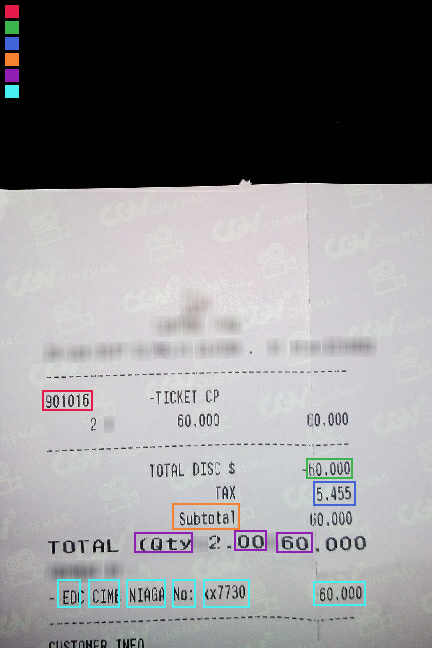

In [ ]:
# Try on a CORD test sample
from IPython.display import display

sample = dataset["test"][0]
img = sample["image"]

result, words, boxes, word_preds = predict(img)

print("=== Line items (one dict per receipt row) ===")
print(json.dumps(result["line_items"], indent=2, ensure_ascii=False))
print("\n=== Summary (subtotal / tax / total / payment) ===")
print(json.dumps(result["summary"], indent=2, ensure_ascii=False))
print("\n=== Flat fields (backward-compatible) ===")
print(json.dumps(result["fields"], indent=2, ensure_ascii=False))

display(visualize(img, words, boxes, word_preds))
